In [3]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
df = pd.read_csv("..\..\data\metadata_(for_scores).csv")
df.head()

,img_id,patient_id,lesion_id,gender,skin_cancer_diagnosis,diagnostic,biopsed,mask_components,melanoma_color_count,melanoma_colors,...,worst_score,Polsby-Popper,convexity_score,lesion_red_share,lesion_green_share,lesion_blue_share,lesion_skin_red_diff,lesion_skin_green_diff,lesion_skin_blue_diff,lesion_skin_rgb_distance
0,PAT_684_1303_368.png,PAT_684,1303,MALE,1,BCC,True,2,1,blue_gray,...,0.228736,0.077357,0.966073,0.385627,0.316149,0.298224,-4.110664,-4.335522,-3.519299,6.933958
1,PAT_842_1606_971.png,PAT_842,1606,FEMALE,1,BCC,True,3,1,blue_gray,...,0.421654,0.074749,0.968111,0.347777,0.307446,0.344777,-8.710226,-22.357424,-8.463104,25.443006
2,PAT_113_172_610.png,PAT_113,172,MALE,1,SCC,True,2,2,"red, blue_gray",...,0.274315,0.078801,0.982251,0.446228,0.283676,0.270096,7.774562,-7.024822,-2.797506,10.845182
3,PAT_1633_2855_460.png,PAT_1633,2855,NaN,0,ACK,False,5,0,NaN,...,0.658751,0.058700,0.981541,0.425111,0.309371,0.265518,16.566090,18.314028,26.037217,35.885591
4,PAT_168_262_74.png,PAT_168,262,MALE,1,BCC,True,1,1,blue_gray,...,0.323160,0.098814,0.964321,0.417867,0.292136,0.289997,-12.708808,-19.862190,-18.049245,29.695044


In [ ]:
x = df[['melanoma_color_count', 'hue_variance', 'saturation_variance', 'value_variance', 
        'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score', 
        'Polsby-Popper', 'convexity_score', 'lesion_red_share', 
        'lesion_green_share', 'lesion_blue_share', 'lesion_skin_red_diff', 
        'lesion_skin_green_diff', 'lesion_skin_blue_diff', 'lesion_skin_rgb_distance']]
y = df['skin_cancer_diagnosis']

In [5]:
x = df[['lesion_green_share', 'mabrouk_asymmetry_score', 'saturation_variance',
       'melanoma_color_count', 'convexity_score', 'avg_asymmetry_score',
       'lesion_red_share', 'worst_score', 'lesion_skin_green_diff',
       'lesion_skin_red_diff']]
y = df['skin_cancer_diagnosis']

In [6]:
from sklearn.model_selection import train_test_split


dev_x, test_x, dev_y, test_y = train_test_split(
        x, y, stratify=y, random_state=0)

train_x, val_x, train_y, val_y = train_test_split(
        dev_x, dev_y, stratify=dev_y, random_state=0)

In [7]:
x

,lesion_green_share,mabrouk_asymmetry_score,saturation_variance,melanoma_color_count,convexity_score,avg_asymmetry_score,lesion_red_share,worst_score,lesion_skin_green_diff,lesion_skin_red_diff
0,0.316149,0,0.014368,1,0.966073,0.194220,0.385627,0.228736,-4.335522,-4.110664
1,0.307446,0,0.001537,1,0.968111,0.299689,0.347777,0.421654,-22.357424,-8.710226
2,0.283676,0,0.018044,2,0.982251,0.194455,0.446228,0.274315,-7.024822,7.774562
3,0.309371,0,0.001702,0,0.981541,0.492774,0.425111,0.658751,18.314028,16.566090
4,0.292136,0,0.015162,1,0.964321,0.213311,0.417867,0.323160,-19.862190,-12.708808
...,...,...,...,...,...,...,...,...,...,...
2089,0.338470,0,0.000370,0,0.974230,0.209648,0.400132,0.267352,-22.214268,-45.803908
2090,0.242980,0,0.002899,0,0.988129,0.139550,0.548378,0.178354,-9.251593,-1.780611
2091,0.300102,0,0.004829,0,0.990189,0.128168,0.432611,0.208479,-23.504266,-16.706975
2092,0.269573,1,0.006313,0,0.964640,0.242514,0.422920,0.271539,-39.457351,-4.347811


In [8]:
decision_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=1907,
    
    )
decision_tree.fit(train_x, train_y)

print(f"Mean accuracy: {decision_tree.score(val_x, val_y)}")
print(f"Train accuracy: {decision_tree.score(train_x, train_y)}")

Mean accuracy: 0.6539440203562341
Train accuracy: 1.0


In [9]:
#fig, ax = plt.subplots(2, 3, figsize=(10, 6))
depths = range(1, 9)

for i, d in enumerate(depths):
    decision_tree = DecisionTreeClassifier(max_depth=d, random_state=1907)
    decision_tree.fit(train_x,train_y)

    # plot
    #row, col = i // 3, i % 3
    #DecisionBoundaryDisplay.from_estimator(decision_tree,train_x,alpha=0.5, ax=ax[row, col])
    #ax[row, col].scatter(val_x[:,0],val_x[:,1],c=val_y)
    #ax[row, col].set_title(f"max_depth={d}")
    print(f"max_depth= {d} - Train accuracy: {decision_tree.score(train_x,train_y)} - Val accuracy: {decision_tree.score(val_x,val_y)}")

max_depth= 1 - Train accuracy: 0.6677994902293968 - Val accuracy: 0.6717557251908397
max_depth= 2 - Train accuracy: 0.6949872557349193 - Val accuracy: 0.6870229007633588
max_depth= 3 - Train accuracy: 0.719626168224299 - Val accuracy: 0.7099236641221374
max_depth= 4 - Train accuracy: 0.7417162276975361 - Val accuracy: 0.7251908396946565
max_depth= 5 - Train accuracy: 0.7672047578589635 - Val accuracy: 0.6997455470737913
max_depth= 6 - Train accuracy: 0.7960917587085812 - Val accuracy: 0.6921119592875318
max_depth= 7 - Train accuracy: 0.8385726423109601 - Val accuracy: 0.7022900763358778
max_depth= 8 - Train accuracy: 0.8751062022090059 - Val accuracy: 0.6819338422391857


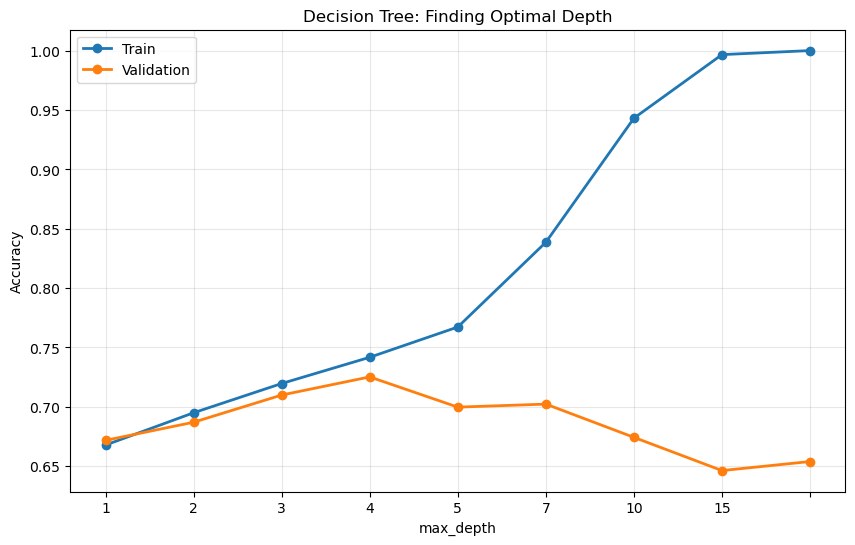

In [10]:
depths = [1, 2, 3, 4, 5, 7, 10, 15, None]
train_accs = []
val_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=1907)
    dt.fit(train_x, train_y)
    train_accs.append(dt.score(train_x, train_y))
    val_accs.append(dt.score(val_x, val_y))

plt.figure(figsize=(10, 6))
plt.plot(range(len(depths)), train_accs, marker='o', label='Train', linewidth=2)
plt.plot(range(len(depths)), val_accs, marker='o', label='Validation', linewidth=2)
plt.xticks(range(len(depths)), depths)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Decision Tree: Finding Optimal Depth')
plt.grid(True, alpha=0.3)
plt.show()

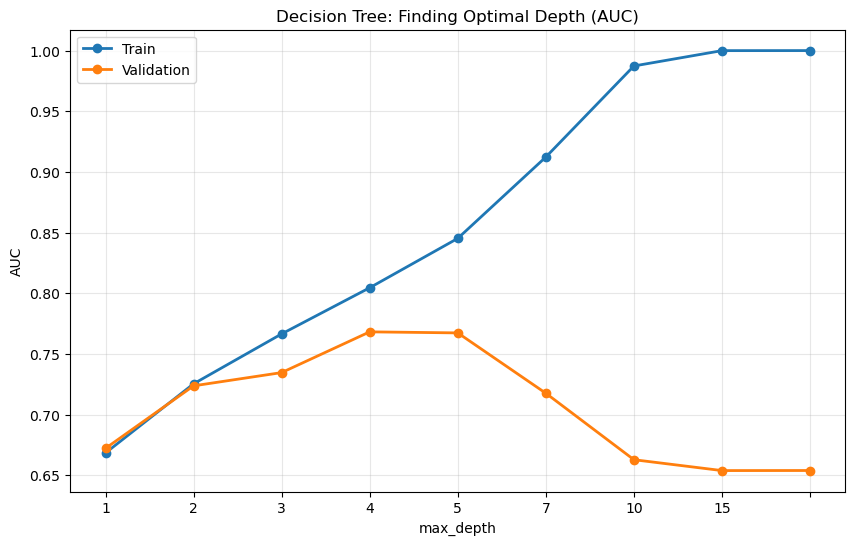

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

depths = [1, 2, 3, 4, 5, 7, 10, 15, None]
train_aucs = []
val_aucs = []


for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=1907)
    dt.fit(train_x, train_y)

    train_probs = dt.predict_proba(train_x)[:, 1]
    val_probs = dt.predict_proba(val_x)[:, 1]

    train_aucs.append(roc_auc_score(train_y, train_probs))
    val_aucs.append(roc_auc_score(val_y, val_probs))

plt.figure(figsize=(10, 6))
plt.plot(range(len(depths)), train_aucs, marker='o', label='Train', linewidth=2)
plt.plot(range(len(depths)), val_aucs, marker='o', label='Validation', linewidth=2)

plt.xticks(range(len(depths)), depths)
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Decision Tree: Finding Optimal Depth (AUC)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

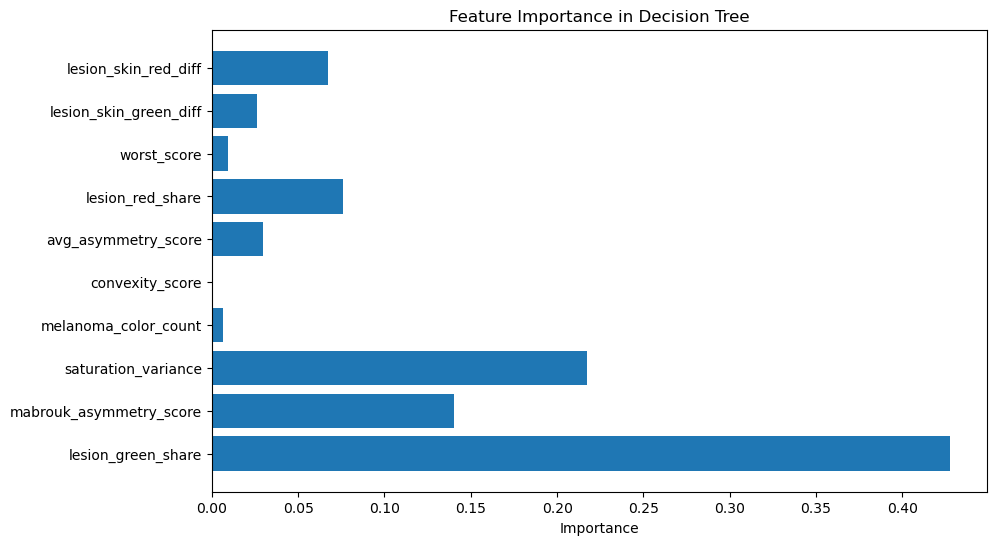

In [13]:
# Train your best model
dt = DecisionTreeClassifier(max_depth=5, random_state=1907)
dt.fit(train_x, train_y)

# See which features are most important
feature_names = ['lesion_green_share', 'mabrouk_asymmetry_score', 'saturation_variance',
       'melanoma_color_count', 'convexity_score', 'avg_asymmetry_score',
       'lesion_red_share', 'worst_score', 'lesion_skin_green_diff',
       'lesion_skin_red_diff']

plt.figure(figsize=(10, 6))
plt.barh(feature_names, dt.feature_importances_)
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.show()